In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import math 

In [18]:
games = pd.read_csv('/datasets/games.csv')
print(games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [19]:
games.columns = games.columns.str.lower()

In [20]:
games['year_of_release'] = games['year_of_release'].astype('Int64')
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')


In [21]:
games.duplicated().sum()

0

In [22]:
games['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', nan], dtype=object)

In [23]:
games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

En los datos se hicieron varias correcciones. En primer lugar, se replazaron los nombres de las columnas en minúsculas para facilitar operaciones y búsqueda más adelante. Ahora, se hizo el cambio de tipo de dos columnas, la columna de 'year_of_release' de float a int. Asimismo, la columna de 'user_score' se cambió de object a float ya que el dato principal que se espera en esta columna son numeros decimales, y se añadió el argumento 'errors=coerce' para que cualquier dato que no fuera un número se pasara a 'NaN', esto incluye también a los valores TBD. Se decidió no rellenar los valores NaN en este dataset porque pueden representar juegos recién lanzados que aún no tienen suficientes reseñas de usuarios o juegos que no han sido evaluados por usuarios todavía entonces mantener los NaN es especialmente importante porque preserva la integridad de los datos no se introducen sesgos artificiales y permite un análisis más preciso y pasa el mismo caso en las otras columnas donde tenemos valores ausentes.

In [24]:
games['total_sales'] = games['na_sales'] + games['jp_sales'] + games['eu_sales']
games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,74.09
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,39.47
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,32.23
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,29.82
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,30.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


In [25]:
year_games = games.groupby('year_of_release')['name'].count()
year_games

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64

Los datos muestran un crecimiento muy marcado en el número de juegos lanzados por año desde inicios de los años 80 hasta un pico alrededor de 2008–2009 (más de 1,400 lanzamientos), lo que refleja una fuerte expansión de la industria. Posteriormente, se observa una caída considerable a partir de 2010 y una estabilización en niveles más bajos. En cuanto a la significancia, los primeros años (1981–1990) presentan volúmenes muy bajos, por lo que pueden no ser representativos para análisis comparativos amplios; en cambio, el período de mayor producción (1995–2011) sí resulta más significativo por su mayor tamaño y dinamismo, mientras que la etapa posterior podría reflejar cambios estructurales del mercado más que una simple disminución de actividad.

In [26]:
top_platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
top_platform_sales = top_platform_sales.head(10).reset_index()
top_platform_sales

,platform,total_sales
0,PS2,1062.33
1,X360,885.66
2,Wii,828.44
3,PS3,803.97
4,DS,746.86
5,PS,689.95
6,GBA,310.12
7,PS4,265.79
8,PSP,252.63
9,XB,249.02


<AxesSubplot:title={'center':'Top Platform Sales'}, xlabel='Year of Release', ylabel='Sales in Millions'>

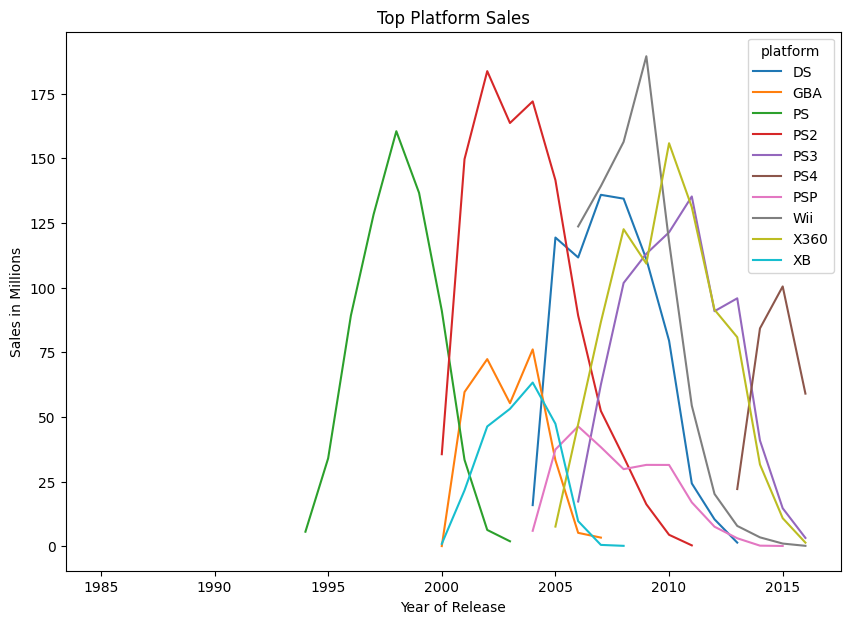

In [27]:
platform_games = games[games['platform'].isin(top_platform_sales['platform'])].groupby(['platform','year_of_release'])['total_sales'].sum().unstack(level=0)
platform_games.plot(kind='line', figsize=(10,7),title='Top Platform Sales',ylabel='Sales in Millions', xlabel='Year of Release')


Con base en la gráfica, las nuevas plataformas suelen aparecer aproximadamente cada 4 a 6 años, coincidiendo con los ciclos generacionales de consolas (por ejemplo, PS → PS2 → PS3 → PS4). En cuanto a la desaparición, las plataformas antiguas generalmente tardan entre 8 y 12 años en salir completamente del mercado, ya que sus ventas disminuyen de forma gradual mientras conviven varios años con la nueva generación. Esto refleja un ciclo típico donde hay solapamiento entre generaciones antes de que la plataforma anterior desaparezca casi por completo.

In [28]:
games[games['platform']=='PS4'].groupby('year_of_release').size()

year_of_release
2013     16
2014     75
2015    137
2016    164
dtype: int64

In [29]:
games_filtered = games[games['year_of_release']>=2014]
games_filtered

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,12.25
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,10.65
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,NaN,10.94
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,7.30
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


In [30]:
games_filtered[games_filtered['platform']=='PS4'].groupby('year_of_release').size()

year_of_release
2014     75
2015    137
2016    164
dtype: int64

In [31]:
games_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     243.67
XOne    127.84
3DS      83.00
PS3      58.81
X360     43.87
WiiU     39.82
PC       25.20
PSV      20.59
Wii       4.67
PSP       0.36
Name: total_sales, dtype: float64

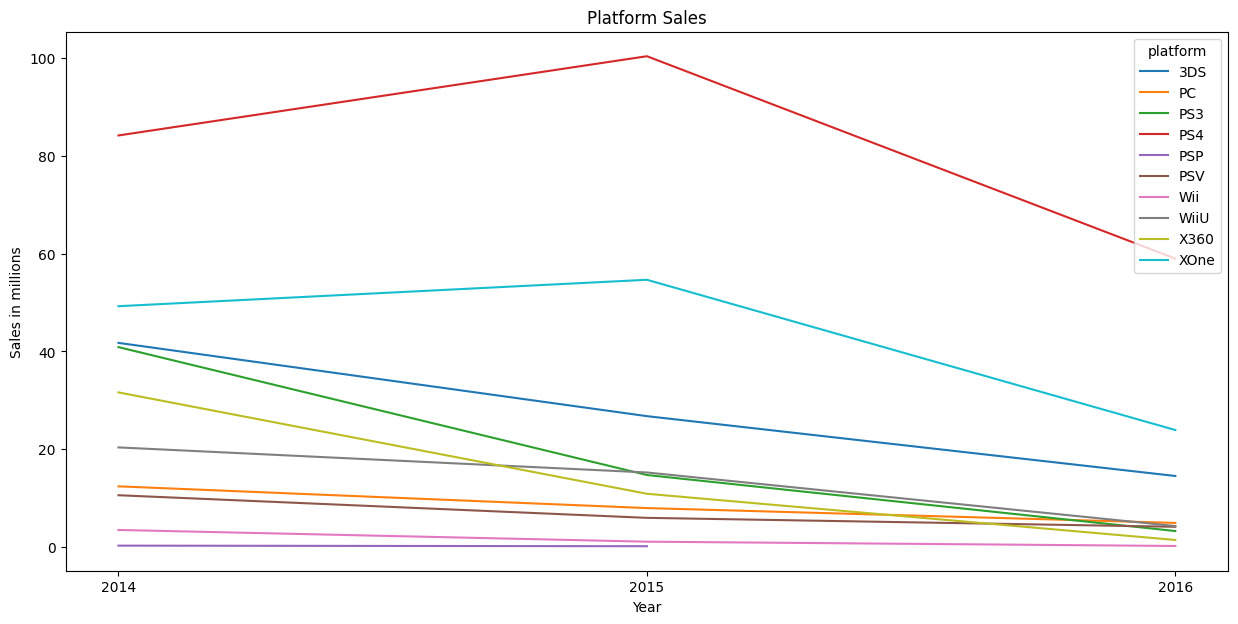

In [32]:
games_filtered_line = games_filtered.groupby(['platform','year_of_release'])['total_sales'].sum().unstack(level=0)
games_filtered_line.plot(kind='line',figsize=(15,7),xlabel='Year',ylabel='Sales in millions',title='Platform Sales')
plt.xticks([2014, 2015, 2016])
plt.show()

Se decidió filtrar el dataframe a partir del año 2014 que fue lo que se consideró como la información más relevante y que nos puede ayudar a construir un modelo productivo más adelante. Se puede observar que las plataformas que está liderando en ventas, a partir de los 2014, son la PS4, XOne y la 3DS consecutivamente.
Se puede observar que la PS4 tuvo un pico en el 2015 con casi 100 millones de ventas y le sigue la XOne con alrededor de 50 millones en el mismo año. En general, todas las plataformas muestran un declive en sus ventas pero esto puede deberse más a un cesgo en la información que no se encuentra tanta información de los últimos años de las paltaformas.

(0.0, 1.75)

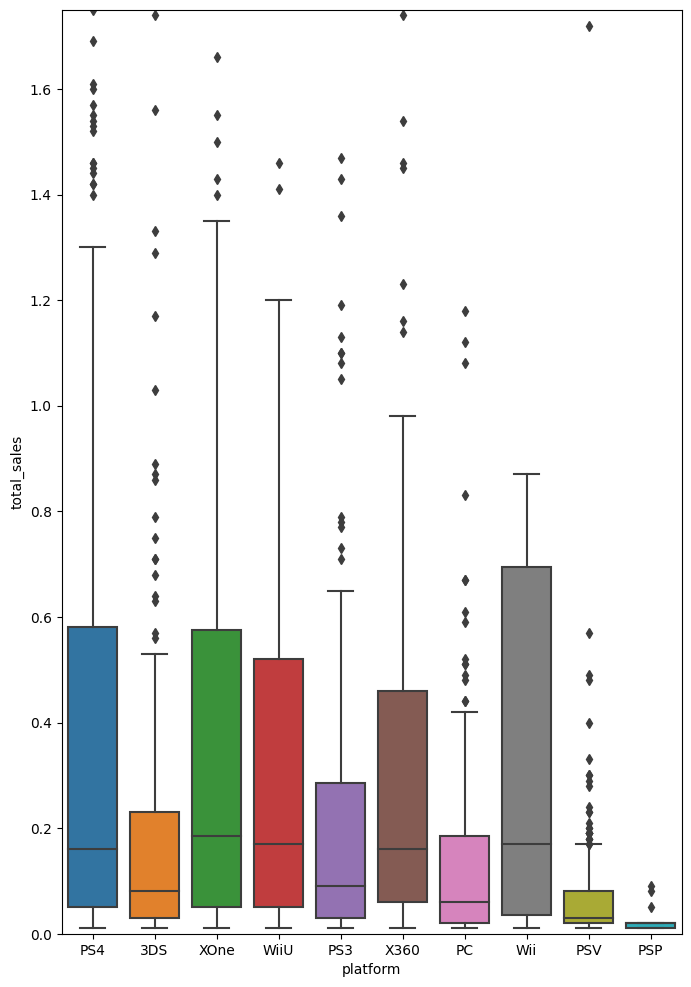

In [33]:
plt.figure(figsize=(8,12))
sns.boxplot(data=games_filtered,x='platform',y='total_sales')
plt.ylim(0,1.75)


Sí, las diferencias en las ventas son significativas entre plataformas. En el diagrama de cajas se observa que PS4, XOne y Wii presentan medianas más altas y mayor dispersión, lo que indica mayores ventas promedio y también una mayor variabilidad en el desempeño de sus juegos. En contraste, PSP y PSV muestran medianas muy bajas y poca dispersión, reflejando ventas generalmente menores y más concentradas en rangos bajos. Plataformas como PS3, X360 y WiiU se ubican en un punto intermedio, con ventas promedio moderadas pero con presencia de valores atípicos (juegos con ventas muy altas). En general, la mayoría de los juegos en todas las plataformas tienen ventas bajas (medianas pequeñas), mientras que unos pocos títulos exitosos elevan el promedio y generan colas superiores pronunciadas.

In [34]:
ps4_filtered = games_filtered[games_filtered['platform']=='PS4'][['critic_score','user_score','total_sales']].reset_index()
ps4_filtered['user_score'] = ps4_filtered['user_score'] * 10
ps4_filtered

,index,critic_score,user_score,total_sales
0,31,NaN,NaN,12.25
1,42,97.0,83.0,10.65
2,77,82.0,43.0,7.30
3,87,NaN,NaN,6.70
4,92,83.0,57.0,6.43
...,...,...,...,...
371,16500,69.0,75.0,0.01
372,16503,NaN,NaN,0.01
373,16526,61.0,79.0,0.01
374,16530,51.0,55.0,0.01


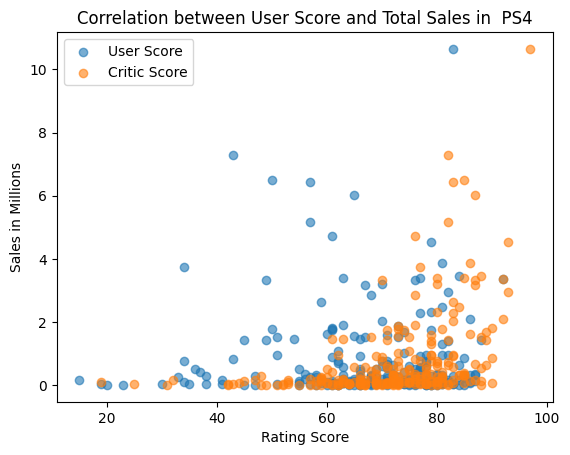

In [35]:
plt.scatter(ps4_filtered['user_score'], ps4_filtered['total_sales'], label='User Score', alpha=0.6)
plt.scatter(ps4_filtered['critic_score'], ps4_filtered['total_sales'], label='Critic Score', alpha=0.6)
plt.title('Correlation between User Score and Total Sales in  PS4')
plt.legend(['User Score','Critic Score'])
plt.ylabel('Sales in Millions')
plt.xlabel('Rating Score')
plt.show()

In [36]:
print(ps4_filtered['critic_score'].corr(ps4_filtered['total_sales']))
ps4_filtered['user_score'].corr(ps4_filtered['total_sales'])

0.4021203477635432


-0.03936434521328732

La gráfica y los coeficientes de correlación indican que existe una correlación positiva moderada entre la calificación de la crítica y las ventas (≈ 0.40), lo que sugiere que, en general, los juegos mejor evaluados por críticos tienden a vender más, aunque la relación no es fuerte. En cambio, la correlación entre la calificación de usuarios y las ventas es prácticamente nula y ligeramente negativa (≈ -0.04), lo que indica que las opiniones de los usuarios no muestran una relación clara con el volumen de ventas. En conclusión, las reseñas de la crítica parecen tener mayor asociación con el desempeño comercial que las calificaciones de los usuarios, aunque otros factores probablemente influyen de manera importante en las ventas.

In [37]:

xone_filtered = games_filtered[games_filtered['platform']=='XOne'][['critic_score','user_score','total_sales']].reset_index()
xone_filtered['user_score'] = xone_filtered['user_score'] * 10
xone_filtered


,index,critic_score,user_score,total_sales
0,99,NaN,NaN,6.71
1,165,97.0,79.0,5.00
2,179,81.0,54.0,4.78
3,242,84.0,64.0,4.08
4,270,88.0,62.0,3.84
...,...,...,...,...
223,16630,63.0,82.0,0.01
224,16643,NaN,66.0,0.01
225,16645,NaN,NaN,0.01
226,16660,74.0,67.0,0.01


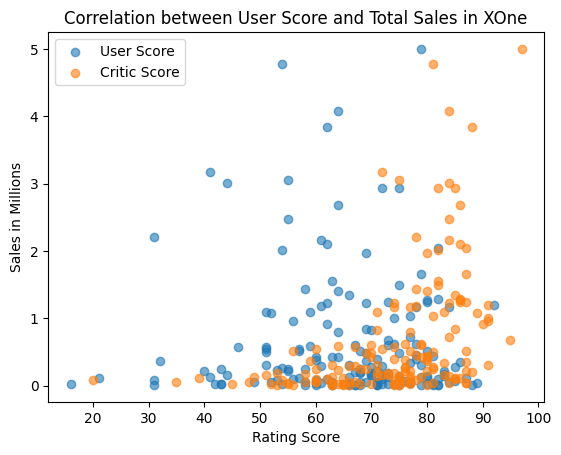

In [38]:
plt.scatter(xone_filtered['user_score'], xone_filtered['total_sales'], label='User Score', alpha=0.6)
plt.scatter(xone_filtered['critic_score'], xone_filtered['total_sales'], label='Critic Score', alpha=0.6)
plt.title('Correlation between User Score and Total Sales in XOne')
plt.legend(['User Score','Critic Score'])
plt.ylabel('Sales in Millions')
plt.xlabel('Rating Score')
plt.show()

In [39]:
print(xone_filtered['critic_score'].corr(xone_filtered['total_sales']))
xone_filtered['user_score'].corr(xone_filtered['total_sales'])

0.4286498963779635


-0.07039252638189665

Al comparar PS4 y XOne, el patrón es prácticamente el mismo. En ambas plataformas existe una correlación positiva moderada entre la calificación de la crítica y las ventas (PS4 ≈ 0.40; XOne ≈ 0.43), siendo ligeramente más fuerte en XOne. En cambio, la correlación entre la calificación de usuarios y las ventas es prácticamente nula y levemente negativa en ambos casos (PS4 ≈ -0.04; XOne ≈ -0.07).

In [24]:
n3ds_filtered = games_filtered[games_filtered['platform']=='3DS'][['critic_score','user_score','total_sales']].reset_index()
n3ds_filtered['user_score'] = n3ds_filtered['user_score'] * 10
n3ds_filtered

,index,critic_score,user_score,total_sales
0,47,NaN,NaN,10.94
1,96,NaN,NaN,7.07
2,108,NaN,NaN,6.69
3,312,86.0,87.0,3.78
4,406,NaN,NaN,3.27
...,...,...,...,...
207,16599,NaN,NaN,0.01
208,16608,NaN,NaN,0.01
209,16610,NaN,NaN,0.01
210,16668,NaN,NaN,0.01


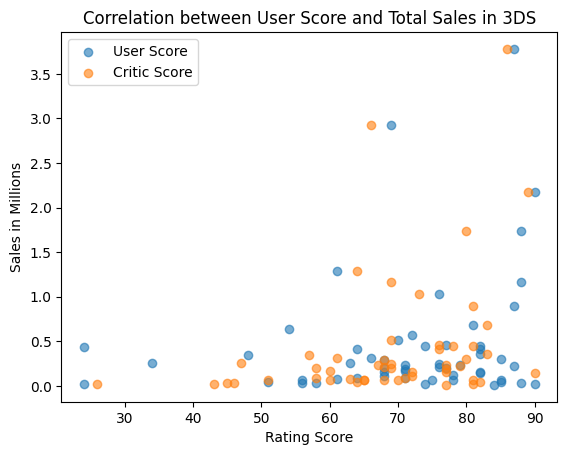

In [25]:
plt.scatter(n3ds_filtered['user_score'], n3ds_filtered['total_sales'], label='User Score', alpha=0.6)
plt.scatter(n3ds_filtered['critic_score'], n3ds_filtered['total_sales'], label='Critic Score', alpha=0.6)
plt.title('Correlation between User Score and Total Sales in 3DS')
plt.legend(['User Score','Critic Score'])
plt.ylabel('Sales in Millions')
plt.xlabel('Rating Score')
plt.show()

In [26]:
print(n3ds_filtered['critic_score'].corr(n3ds_filtered['total_sales']))
n3ds_filtered['user_score'].corr(n3ds_filtered['total_sales'])

0.3117520311601232


0.21461640035191545

En 3DS se observa un comportamiento diferente respecto a PS4 y XOne. La correlación entre critic score y ventas es positiva pero más débil (≈ 0.31), lo que indica una relación moderada-baja. Por otro lado, la correlación entre user score y ventas también es positiva (≈ 0.21), aunque aún más débil.
A diferencia de PS4 y XOne —donde la calificación de usuarios prácticamente no tenía relación con las ventas— en 3DS ambas variables muestran cierta asociación positiva, aunque ninguna es fuerte.

In [40]:
genre_filtered = games_filtered.groupby('genre')['total_sales'].sum()
genre_filtered

genre
Action          176.79
Adventure        15.73
Fighting         25.49
Misc             33.52
Platform         16.28
Puzzle            2.10
Racing           24.63
Role-Playing     92.80
Shooter         149.41
Simulation       12.24
Sports           95.12
Strategy          3.72
Name: total_sales, dtype: float64

<AxesSubplot:title={'center':'Sales by Genre'}, xlabel='Genre', ylabel='Sales in Millions'>

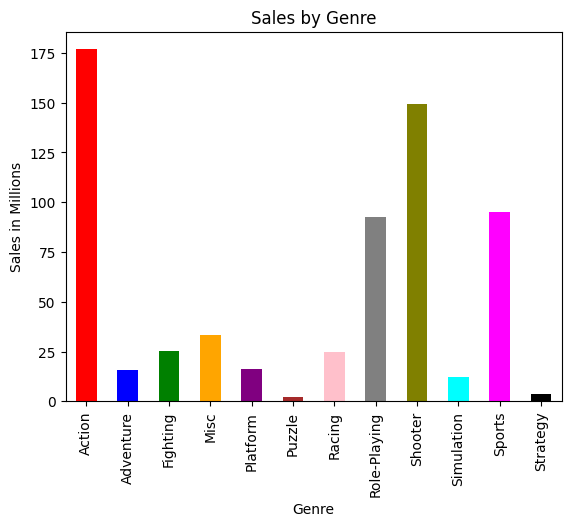

In [41]:
genre_filtered.plot(kind='bar', xlabel='Genre',ylabel='Sales in Millions',title='Sales by Genre',color=['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 
          'gray', 'olive', 'cyan', 'magenta', 'black'])


Los géneros más rentables son claramente Action (176.79) y Shooter (149.41), seguidos por Sports (95.12) y Role-Playing (92.80), lo que indica que los juegos de acción intensa, disparos y deportes dominan en ventas. En contraste, géneros como Puzzle (2.10) y Strategy (3.72) muestran ventas considerablemente más bajas. En general, se puede concluir que los géneros orientados a acción dinámica y experiencias competitivas tienden a generar mayores ingresos, mientras que los géneros más nicho o de ritmo más pausado suelen presentar menores niveles de ventas.

In [42]:
na_filtered_plat = games_filtered.groupby('platform')['na_sales'].sum().reset_index().sort_values(by='na_sales',ascending=False)
na_filtered_plat = na_filtered_plat.head(5)
na_filtered_plat

,platform,na_sales
3,PS4,98.61
9,XOne,81.27
8,X360,28.30
0,3DS,22.64
2,PS3,22.05


In [43]:
eu_filtered_plat = games_filtered.groupby('platform')['eu_sales'].sum().reset_index().sort_values(by='eu_sales',ascending=False)
eu_filtered_plat = eu_filtered_plat.head(5)
eu_filtered_plat

,platform,eu_sales
3,PS4,130.04
9,XOne,46.25
2,PS3,25.54
1,PC,17.97
0,3DS,16.12


In [44]:
jp_filtered_plat = games_filtered.groupby('platform')['jp_sales'].sum().reset_index().sort_values(by='jp_sales',ascending=False)
jp_filtered_plat = jp_filtered_plat.head(5)
jp_filtered_plat

,platform,jp_sales
0,3DS,44.24
3,PS4,15.02
5,PSV,14.54
2,PS3,11.22
7,WiiU,7.31


Las cuotas de mercado varían claramente entre regiones. En Norteamérica (NA) domina PS4 (98.61) seguida de XOne (81.27), lo que muestra una fuerte preferencia por consolas de sobremesa occidentales, mientras que X360 aún mantiene presencia relevante. En Europa (EU) también lidera PS4 (130.04) con una ventaja aún mayor, pero XOne (46.25) queda bastante más rezagada, y plataformas como PC ganan mayor peso relativo. En cambio, en Japón (JP) el mercado es distinto: domina 3DS (44.24), y las consolas portátiles como PSV (14.54) tienen un papel importante, mientras que Xbox prácticamente no aparece entre las principales. En general, Occidente favorece consolas de sobremesa como PS4 y Xbox, mientras que Japón muestra una preferencia marcada por consolas portátiles y plataformas de origen local.

In [45]:
na_filtered_genre = games_filtered.groupby('genre')['na_sales'].sum().reset_index().sort_values(by='na_sales',ascending=False)
na_filtered_genre = na_filtered_genre.head(5)
na_filtered_genre

,genre,na_sales
8,Shooter,79.02
0,Action,72.53
10,Sports,46.13
7,Role-Playing,33.47
3,Misc,15.05


In [46]:
eu_filtered_genre = games_filtered.groupby('genre')['eu_sales'].sum().reset_index().sort_values(by='eu_sales',ascending=False)
eu_filtered_genre = eu_filtered_genre.head(5)
eu_filtered_genre

,genre,eu_sales
0,Action,74.68
8,Shooter,65.52
10,Sports,45.73
7,Role-Playing,28.17
6,Racing,14.13


In [47]:
jp_filtered_genre = games_filtered.groupby('genre')['jp_sales'].sum().reset_index().sort_values(by='jp_sales',ascending=False)
jp_filtered_genre = jp_filtered_genre.head(5)
jp_filtered_genre

,genre,jp_sales
7,Role-Playing,31.16
0,Action,29.58
2,Fighting,6.37
3,Misc,5.61
8,Shooter,4.87


Las diferencias entre regiones son claras en cuanto a preferencias de género. En Norteamérica, predominan Shooter (79.02) y Action (72.53), lo que refleja una fuerte inclinación por juegos de acción intensa y competitiva, seguidos por Sports. En Europa, aunque Action (74.68) lidera, Shooter (65.52) mantiene gran popularidad y Sports conserva un peso similar al de NA, mostrando un patrón bastante parecido al mercado norteamericano. En cambio, en Japón destaca principalmente Role-Playing (31.16), seguido de Action, mientras que los Shooter tienen una presencia mucho menor. Además, géneros como Fighting aparecen en el top japonés pero no en Occidente. En general, Occidente favorece acción, disparos y deportes, mientras que Japón muestra una preferencia más marcada por RPG y géneros asociados a franquicias y estilos de juego más narrativos o tradicionales.

In [48]:
na_filtered_rating = games_filtered.groupby('rating')['na_sales'].sum().reset_index().sort_values(by='na_sales',ascending=False)
na_filtered_rating = na_filtered_rating.head(5)
na_filtered_rating

,rating,na_sales
2,M,96.42
0,E,50.74
3,T,38.95
1,E10+,33.23


In [49]:
eu_filtered_rating = games_filtered.groupby('rating')['eu_sales'].sum().reset_index().sort_values(by='eu_sales',ascending=False)
eu_filtered_rating = eu_filtered_rating.head(5)
eu_filtered_rating

,rating,eu_sales
2,M,93.44
0,E,58.06
3,T,34.07
1,E10+,26.16


In [50]:
jp_filtered_rating = games_filtered.groupby('rating')['jp_sales'].sum().reset_index().sort_values(by='jp_sales',ascending=False)
jp_filtered_rating = jp_filtered_rating.head(5)
jp_filtered_rating

,rating,jp_sales
3,T,14.78
0,E,8.94
2,M,8.01
1,E10+,4.46


Sí, las clasificaciones de ESRB parecen estar asociadas a diferencias claras en ventas según la región. En Norteamérica y Europa, los juegos con clasificación M (Mature) lideran ampliamente las ventas (96.42 y 93.44 respectivamente), lo que indica una fuerte demanda de contenido orientado a adultos; les siguen las clasificaciones E y T, pero con una brecha considerable. En cambio, en Japón el patrón cambia: la clasificación más vendida es T (Teen) (14.78), mientras que M tiene un peso mucho menor (8.01). Esto sugiere que en Occidente el mercado adulto domina el volumen de ventas, mientras que en Japón hay mayor preferencia por contenidos dirigidos a adolescentes o públicos más amplios. En conclusión, la clasificación por edad sí se relaciona con el desempeño comercial y su impacto varía según la región.

In [55]:
xone_score = games_filtered[games_filtered['platform']=='XOne']['user_score']
pc_score = games_filtered[games_filtered['platform']=='PC']['user_score']

In [56]:
xone_score_clean = xone_score.dropna()
print(xone_score_clean.mean())
print(xone_score_clean.var())
xone_score_clean.std()

6.594545454545456
1.8910066518847013


1.375138775500386

In [57]:
pc_score_clean = pc_score.dropna()
print(pc_score_clean.mean())
print(pc_score_clean.var())
pc_score_clean.std()

6.298360655737705
2.901154315133451


1.7032775214666138

In [58]:
#Hipótesis Nula = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
#Hipótesis Alternativa = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

alpha = 0.05


results = st.ttest_ind(xone_score_clean, pc_score_clean, equal_var=False)

print('valor p:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")

else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.11601398086668832
No podemos rechazar la hipótesis nula


Aunque la media de Xbox One (6.59) es ligeramente superior a la de PC (6.30), la prueba t (p = 0.116 > 0.05) indica que esta diferencia no es estadísticamente significativa. Además, PC presenta mayor varianza (2.90 vs 1.89) y mayor desviación estándar (1.70 vs 1.38), lo que muestra que las calificaciones en PC están más dispersas, mientras que en Xbox One son más consistentes. En conjunto, aunque Xbox One tiene un promedio ligeramente más alto y menor variabilidad, no existe evidencia suficiente para afirmar que las calificaciones promedio entre ambas plataformas sean realmente diferentes.

In [59]:
action_score = games_filtered[games_filtered['genre']=='Action']['user_score']
sports_score = games_filtered[games_filtered['genre']=='Sports']['user_score']

In [60]:
action_score_clean = action_score.dropna()
print(action_score_clean.mean())
print(action_score_clean.var())
action_score_clean.std()

6.760606060606061
1.8984766584766581


1.3778521903588419

In [61]:
sports_score_clean = sports_score.dropna()
print(sports_score_clean.mean())
print(sports_score_clean.var())
sports_score_clean.std()

5.2251968503937
3.446979127609048


1.8566041925001269

In [62]:
#Hipótesis Nula = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
#Hipótesis Alternativa = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

alpha = 0.05


results = st.ttest_ind(action_score_clean, sports_score_clean, equal_var=False)

print('valor p:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")

else:
    print("No podemos rechazar la hipótesis nula")

valor p: 1.1825550382644557e-14
Rechazamos la hipótesis nula


El género Action presenta una media de calificación de 6.76, mientras que Sports tiene una media considerablemente menor de 5.23, lo que ya muestra una diferencia notable en valoración por parte de los usuarios. Además, Sports tiene mayor varianza (3.45 vs 1.90) y desviación estándar (1.86 vs 1.38), lo que indica opiniones más dispersas y menos consistentes. La prueba t arroja un valor p = 1.18e-14, muy inferior a 0.05, por lo que se rechaza la hipótesis nula. En conclusión, existe una diferencia estadísticamente significativa entre las calificaciones promedio de Acción y Deportes, siendo Acción claramente mejor valorado y con opiniones más homogéneas que Deportes.

Formulación de hipótesis

Las hipótesis se formularon directamente a partir del objetivo del ejercicio: comparar calificaciones promedio de usuarios entre dos grupos independientes. En ambos casos, el interés era determinar si las diferencias observadas en las medias podían atribuirse al azar o si reflejaban una diferencia real en la población.

Para Xbox One vs PC, se estableció como hipótesis nula que las medias son iguales, porque en contraste de hipótesis lo estándar es asumir inicialmente que no hay diferencia. La hipótesis alternativa plantea que las medias son diferentes, lo que permite detectar cualquier diferencia significativa sin asumir dirección específica.

Para Acción vs Deportes, se siguió la misma lógica: la hipótesis nula establece igualdad de medias y hipotesis alternativa plantea diferencia entre ellas. En este caso, la prueba busca determinar si la diferencia observada en las calificaciones promedio entre ambos géneros es estadísticamente significativa y no producto de la variabilidad muestral.

Criterio utilizado

Se aplicó una prueba t para muestras independientes porque se comparan medias de dos grupos distintos y las varianzas observadas no son iguales, lo que hace más apropiada esta versión de la prueba. Se utilizó un nivel de significancia α = 0.05, que es el estándar en análisis estadístico, ya que implica aceptar un 5% de probabilidad de cometer un error tipo I (rechazar una hipótesis nula verdadera). Este umbral ofrece un equilibrio razonable entre ser demasiado permisivo y demasiado estricto al evaluar evidencia estadística.

Conclusion:
El análisis revela que la industria de videojuegos experimentó un crecimiento sostenido hasta su punto máximo alrededor de 2008–2009, seguido de una fase de estabilización y ligera contracción. Las plataformas muestran ciclos generacionales definidos (aprox. 5–7 años de auge comercial), lo que implica que la planificación de lanzamientos debe alinearse con ventanas estratégicas claras. En el período reciente (desde 2014), PS4 y Xbox One dominan en mercados occidentales, mientras que 3DS mantiene relevancia en Japón. Sin embargo, se observa una desaceleración general en ventas en los últimos años disponibles, lo que sugiere un mercado más competitivo y menos expansivo que en su etapa de auge.

Desde el punto de vista de rentabilidad por contenido, los géneros Action y Shooter concentran el mayor volumen de ingresos globales, con especial fuerza en Norteamérica y Europa. En contraste, géneros como Puzzle y Strategy presentan menor impacto comercial. Regionalmente existen diferencias marcadas: Occidente favorece títulos de acción con clasificación “M”, mientras que Japón mantiene preferencia por plataformas portátiles y géneros como Role-Playing. Esto implica que la estrategia de portafolio debe adaptarse por región, evitando enfoques homogéneos globales.

En cuanto a factores predictivos de éxito, las reseñas de la crítica muestran una correlación positiva moderada con las ventas, lo que indica que la calidad percibida por expertos sí influye en el rendimiento comercial. Las calificaciones de usuarios, en cambio, presentan una relación débil, por lo que no deben considerarse un indicador principal para proyecciones de ventas. Finalmente, las pruebas estadísticas muestran que no existe diferencia significativa en las calificaciones promedio de usuarios entre Xbox One y PC, pero sí entre los géneros Acción y Deportes, lo que refuerza que el género tiene un impacto más determinante en la percepción del producto que la plataforma en sí.